In [1]:
import os

from notebooks.traingulation import encryptor

os.environ['PROJECT_DIR'] = '/Users/eden.yavin/Projects/Tabular-Cloud-ML'

In [2]:
DATASET_NAME = "mushroom"

In [3]:
from src.dataset import DatasetFactory
raw_dataset = DatasetFactory().get_dataset(DATASET_NAME)
X, y = raw_dataset.get_dataset()
X.shape


Scaling numerical columns...


(8124, 22)

In [4]:
from src.utils.db import RawSplitDBFactory

X_train, X_test, X_sample, y_train, y_test, y_sample = RawSplitDBFactory.get_db(raw_dataset).get_split()
X_test.shape, X_sample.shape

2025-12-12 08:11:43.038 | INFO     | src.embeddings.model:<module>:29 - torch: 1.12.1, torch cuda: None, cuda_available: False
2025-12-12 08:11:43.039 | INFO     | src.embeddings.model:<module>:30 - python: 3.10.14 (main, Mar 19 2024, 21:46:16) [Clang 15.0.0 (clang-1500.3.9.4)]
2025-12-12 08:11:43.039 | INFO     | src.embeddings.model:<module>:31 - tf: 2.16.2, gpus: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
2025-12-12 08:11:43.049 | INFO     | src.utils.db:get_split:82 - mushroom LOADED INDEX 1.0 - INDEX SIZE 7311


python: 3.10.14 (main, Mar 19 2024, 21:46:16) [Clang 15.0.0 (clang-1500.3.9.4)]
torch: 1.12.1 torch cuda: None cuda_available: False
tf: 2.16.2 gpus: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


((813, 22), (7311, 22))

In [5]:
from keras.src.utils import to_categorical

y_train =  to_categorical(y_train, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)
y_sample = to_categorical(y_sample, num_classes=2)

In [6]:
X_sample.shape

(7311, 22)

In [7]:
from src.utils.traingulations import get_triangulation_samples_clustering, get_class_representative_samples

kmeans_tr = get_triangulation_samples_clustering(2, X_sample)
kmeans_tr.shape

(2, 22)

In [8]:
class_rep_tr = get_class_representative_samples(X_sample, y_sample)
class_rep_tr.shape

(2, 22)

In [9]:
from sklearn.decomposition import PCA
import numpy as np

X_all = np.vstack([X_sample, X_test, kmeans_tr, class_rep_tr])
# 3. Dimensionality Reduction (PCA)
pca = PCA(n_components=2)
X_embedded = pca.fit_transform(X_all)

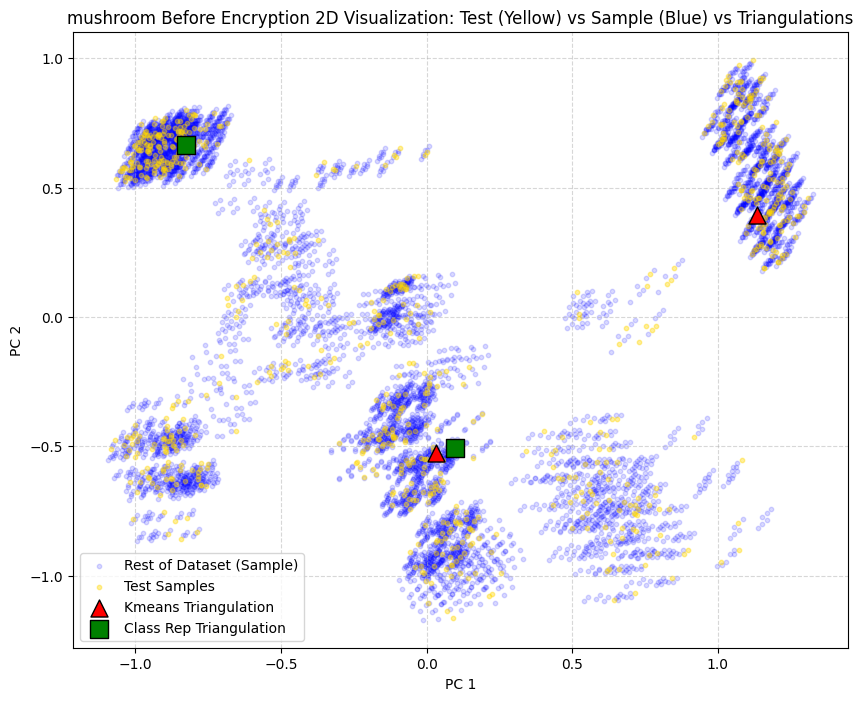

In [10]:
import matplotlib.pyplot as plt

X_sample_2d = X_embedded[:X_sample.shape[0]]
X_test_2d = X_embedded[X_sample.shape[0]:X_sample.shape[0] + X_test.shape[0]]
kmeans_tr_2d = X_embedded[X_sample.shape[0] + X_test.shape[0]:X_sample.shape[0] + X_test.shape[0] +  2]
class_rep_tr_2d = X_embedded[X_sample.shape[0] + X_test.shape[0] + 2: X_sample.shape[0] + X_test.shape[0] + 2 + 2]

# 5. Plotting with explicit white background
fig = plt.figure(figsize=(10, 8), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# Plot Rest of Dataset (X_sample) in Blue
plt.scatter(X_sample_2d[:, 0], X_sample_2d[:, 1], c='blue', alpha=0.15, label='Rest of Dataset (Sample)', s=10)

# Plot Test Samples in Yellow
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c='gold', alpha=0.4, label='Test Samples', s=10)

# Plot Kmeans (Red)
plt.scatter(kmeans_tr_2d[:, 0], kmeans_tr_2d[:, 1], c='red', marker='^', s=150, label='Kmeans Triangulation', edgecolors='black', zorder=10)

# Plot Class Rep (Green)
plt.scatter(class_rep_tr_2d[:, 0], class_rep_tr_2d[:, 1], c='green', marker='s', s=150, label='Class Rep Triangulation', edgecolors='black', zorder=5)

plt.title(f'{DATASET_NAME} Before Encryption 2D Visualization: Test (Yellow) vs Sample (Blue) vs Triangulations')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('triangulation_before_enc.png', facecolor='white')
plt.show()


In [16]:
from src.embeddings import ClipEmbedding, DinoEmbedding
from src.cloud import CLOUD_MODELS, DEFAULT_CLOUD_OUTPUT_SHAPE
from src.encryptor import EncryptorFactory

encryptor = EncryptorFactory.get_model(dataset_name=DATASET_NAME, output_shape=DEFAULT_CLOUD_OUTPUT_SHAPE)
# triangulation_embedding = ClipEmbedding()
# triangulation_embedding = DinoEmbedding()


In [17]:

y_tag1 = encryptor.encode(kmeans_tr)
y_tag2 = encryptor.encode(class_rep_tr)
# 2. Embed the encryption
y_tag_1emb = triangulation_embedding.forward(y_tag1)
y_tag_2emb = triangulation_embedding.forward(y_tag2)

In [18]:
from tqdm.notebook import tqdm
X_sample_enc, X_test_env  = [], []
for x in tqdm(X_sample[:1000], leave=True, total=len(X_sample), position=0):
    x_tag = encryptor.encode(x.reshape(1, -1))
    X_sample_enc.append(triangulation_embedding.forward(np.vstack(x_tag)))
    encryptor.switch_key()

for x in tqdm(X_test, leave=True, total=len(X_test), position=0):
    x_tag = encryptor.encode(x.reshape(1, -1))
    X_test_env.append(triangulation_embedding.forward(np.vstack(x_tag)))
    encryptor.switch_key()

X_sample_enc = np.vstack(X_sample_enc)
X_test_env = np.vstack(X_test_env)

  0%|          | 0/7311 [00:00<?, ?it/s]

  0%|          | 0/813 [00:00<?, ?it/s]

In [19]:
from sklearn.decomposition import PCA
import numpy as np

X_all_enc = np.vstack([X_sample_enc, X_test_env, y_tag_1emb, y_tag_2emb])
# 3. Dimensionality Reduction (PCA)
pca = PCA(n_components=2)
X_embedded_enc = pca.fit_transform(X_all_enc)

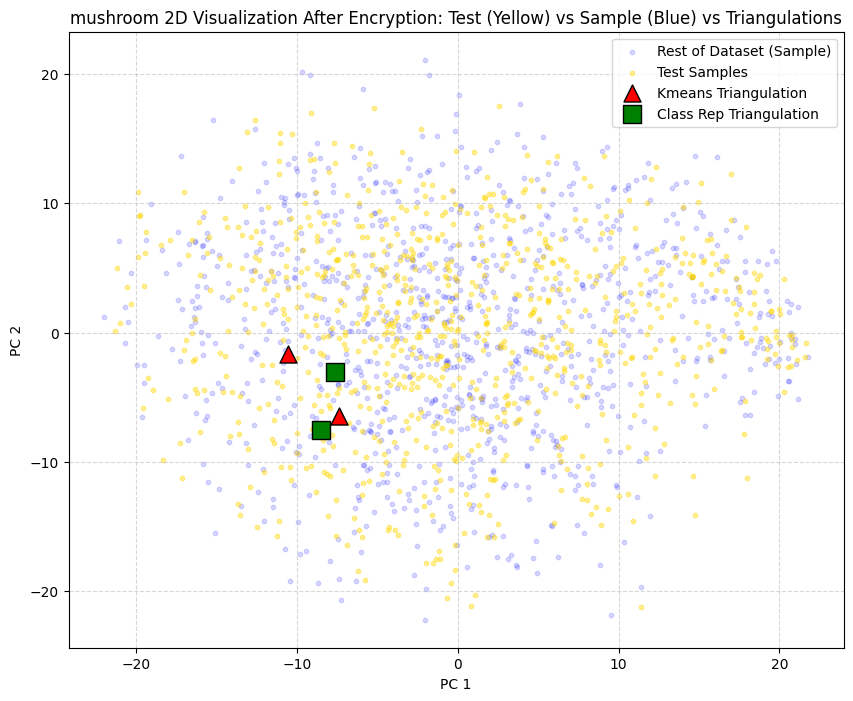

In [20]:
import matplotlib.pyplot as plt

X_sample_2d = X_embedded_enc[:X_sample_enc.shape[0]]
X_test_2d = X_embedded_enc[X_sample_enc.shape[0]:X_sample_enc.shape[0] + X_test_env.shape[0]]
kmeans_tr_2d = X_embedded_enc[X_sample_enc.shape[0] + X_test_env.shape[0]:X_sample_enc.shape[0] + X_test_env.shape[0] +  2]
class_rep_tr_2d = X_embedded_enc[X_sample_enc.shape[0] + X_test_env.shape[0] + 2: X_sample_enc.shape[0] + X_test_env.shape[0] + 2 + 2]

# 5. Plotting with explicit white background
fig = plt.figure(figsize=(10, 8), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# Plot Rest of Dataset (X_sample) in Blue
plt.scatter(X_sample_2d[:, 0], X_sample_2d[:, 1], c='blue', alpha=0.15, label='Rest of Dataset (Sample)', s=10)

# Plot Test Samples in Yellow
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c='gold', alpha=0.4, label='Test Samples', s=10)

# Plot Kmeans (Red)
plt.scatter(kmeans_tr_2d[:, 0], kmeans_tr_2d[:, 1], c='red', marker='^', s=150, label='Kmeans Triangulation', edgecolors='black', zorder=10)

# Plot Class Rep (Green)
plt.scatter(class_rep_tr_2d[:, 0], class_rep_tr_2d[:, 1], c='green', marker='s', s=150, label='Class Rep Triangulation', edgecolors='black', zorder=5)

plt.title(f'{DATASET_NAME} 2D Visualization After Encryption: Test (Yellow) vs Sample (Blue) vs Triangulations')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('triangulation_plot_after_enc.png', facecolor='white')
plt.show()
